In [11]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(le, open('encoder.pkl', 'wb'))

In [13]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kavyanjaliparmar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
df = pd.read_csv('all_tickets_processed_improved_v3.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nSample Data:\n", df.head())

Dataset Shape: (47837, 2)

Columns: Index(['Document', 'Topic_group'], dtype='object')

Sample Data:
                                             Document    Topic_group
0  connection with icon icon dear please setup ic...       Hardware
1  work experience user work experience user hi w...         Access
2  requesting for meeting requesting meeting hi p...       Hardware
3  reset passwords for external accounts re expir...         Access
4  mail verification warning hi has got attached ...  Miscellaneous


In [15]:
TEXT_COL = 'Document'
LABEL_COL = 'Topic_group'

In [16]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)   
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df[TEXT_COL] = df[TEXT_COL].apply(clean_text)

print("\nCleaned Text Sample:\n", df[TEXT_COL].head())


Cleaned Text Sample:
 0    connection icon icon dear please setup icon pe...
1    work experience user work experience user hi w...
2    requesting meeting requesting meeting hi pleas...
3    reset passwords external accounts expire days ...
4    mail verification warning hi got attached plea...
Name: Document, dtype: object


In [17]:
le = LabelEncoder()
y = le.fit_transform(df[LABEL_COL])

print("\nClasses:", le.classes_)


Classes: ['Access' 'Administrative rights' 'HR Support' 'Hardware'
 'Internal Project' 'Miscellaneous' 'Purchase' 'Storage']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [19]:
model = LogisticRegression(max_iter=300)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,300
,multi_class,'deprecated'


In [20]:
y_pred = model.predict(X_test)


In [21]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8506479933110368


In [22]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)



Classification Report:

                       precision    recall  f1-score   support

               Access       0.92      0.87      0.89      1455
Administrative rights       0.86      0.68      0.76       342
           HR Support       0.85      0.84      0.84      2107
             Hardware       0.80      0.89      0.84      2760
     Internal Project       0.92      0.80      0.86       451
        Miscellaneous       0.81      0.83      0.82      1400
             Purchase       0.97      0.87      0.92       497
              Storage       0.93      0.84      0.89       556

             accuracy                           0.85      9568
            macro avg       0.88      0.83      0.85      9568
         weighted avg       0.85      0.85      0.85      9568


Confusion Matrix:
 [[1265    3   38   97    1   44    0    7]
 [   5  231   13   82    0   10    1    0]
 [  30    6 1764  205   11   80    1   10]
 [  45   22  122 2447    4  100    8   12]
 [   3    0   38   32  3

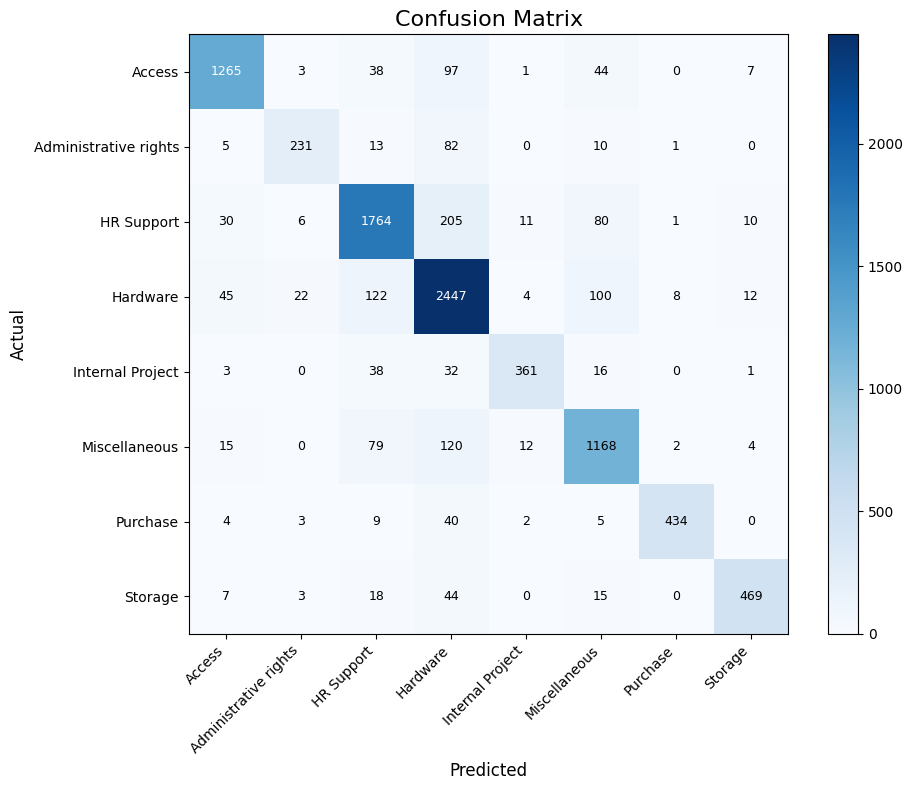

In [23]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))

plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix", fontsize=16)
plt.colorbar()

plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)

# ticks
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45, ha='right')
plt.yticks(range(len(le.classes_)), le.classes_)

threshold = np.max(cm) / 2

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(
            j, i, cm[i][j],
            ha='center',
            va='center',
            color='white' if cm[i][j] > threshold else 'black',  
            fontsize=9
        )

plt.tight_layout()
plt.show()



In [24]:
def assign_priority(text, category):
    text = text.lower()

    if "urgent" in text or "failed" in text or "error" in text:
        return "High"
    elif category in ["Hardware", "Access"]:
        return "Medium"
    else:
        return "Low"


In [25]:
def predict_ticket(text):
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned])

    pred = model.predict(vector)
    category = le.inverse_transform(pred)[0]

    priority = assign_priority(text, category)

    return category, priority

In [26]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(le, open('encoder.pkl', 'wb'))